Enzyme Dataset - Random Forest

In [2]:
import pandas as pd
import numpy as np
import time
import seaborn as sns
# import matplotlib.pyplot as plt
# import plotly.graph_objects as go
# from sklearn.metrics import accuracy_score
# from sklearn.svm import SVC
# import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression

df = pd.read_csv('train.csv', index_col='id')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14838 entries, 0 to 14837
Data columns (total 37 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   BertzCT            14838 non-null  float64
 1   Chi1               14838 non-null  float64
 2   Chi1n              14838 non-null  float64
 3   Chi1v              14838 non-null  float64
 4   Chi2n              14838 non-null  float64
 5   Chi2v              14838 non-null  float64
 6   Chi3v              14838 non-null  float64
 7   Chi4n              14838 non-null  float64
 8   EState_VSA1        14838 non-null  float64
 9   EState_VSA2        14838 non-null  float64
 10  ExactMolWt         14838 non-null  float64
 11  FpDensityMorgan1   14838 non-null  float64
 12  FpDensityMorgan2   14838 non-null  float64
 13  FpDensityMorgan3   14838 non-null  float64
 14  HallKierAlpha      14838 non-null  float64
 15  HeavyAtomMolWt     14838 non-null  float64
 16  Kappa3             14838 no

Prediction made on EC1, EC2. Dropping Unnecessary features.

In [3]:
df.drop(['EC3', 'EC4', 'EC5', 'EC6'], axis=1, inplace=True)

In [4]:
X = df.iloc[:, 0:31]
y = df.iloc[:, 31:33]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=104, test_size=0.25, shuffle=True)
y1 = y_train['EC1']
y2 = y_train['EC2']
x1 = y_test['EC1']
x2 = y_test['EC2']

# Define the pipeline with PolynomialFeatures
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('polynomial_features', PolynomialFeatures()),  # Include PolynomialFeatures step
    ('model', LinearRegression())
])

# Define the parameter grid
param_grid = {
    'polynomial_features__degree': [2, 3],  # Tuning the degree of polynomial features
    'polynomial_features__include_bias': [False, True],
    'model__fit_intercept': [True, False]  # Tuning the LinearRegression step
}

# Perform grid search
grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring='r2', n_jobs=-1)  # Use appropriate scoring
grid_search.fit(X_train, y1)

# Print the best parameters and score
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

# Evaluate the model on the test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print("Test R^2 score:", best_model.score(X_test, x1))

Best parameters: {'model__fit_intercept': True, 'polynomial_features__degree': 2, 'polynomial_features__include_bias': False}
Best cross-validation score: -167.6960684680651
Test R^2 score: -72.8228269504488


In [5]:
rf1 = RandomForestClassifier(n_estimators=500, random_state=104)
rf1.fit(X_train, y1)
rf1.score(X_test, x1)

0.7016172506738545

In [6]:
rf2 = RandomForestClassifier(n_estimators=100, random_state=104)
rf2.fit(X_train, y2)
rf2.score(X_test, x2)

0.801078167115903

<Axes: >

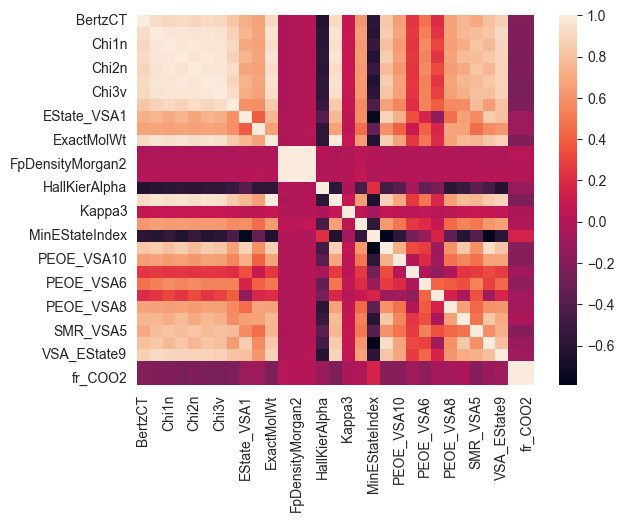

In [7]:
sns.heatmap(X.corr())

In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier

ada_clf = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=3), n_estimators=200,
    learning_rate=0.1, random_state=42)
ada_clf.fit(X_train, y1)
ada_clf.score(X_test, x1)

0.7040431266846361

In [9]:
param_grid = {'learning_rate': [0.01, 0.05, 0.1, 0.5], 'n_estimators': [200],
              'estimator': [DecisionTreeClassifier(max_depth=3), DecisionTreeClassifier(max_depth=5), DecisionTreeClassifier(max_depth=7)]}
grid = GridSearchCV(ada_clf, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid.fit(X_train, y1)

GridSearchCV(cv=5,
             estimator=AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3),
                                          learning_rate=0.1, n_estimators=200,
                                          random_state=42),
             n_jobs=-1,
             param_grid={'estimator': [DecisionTreeClassifier(max_depth=3),
                                       DecisionTreeClassifier(max_depth=5),
                                       DecisionTreeClassifier(max_depth=7)],
                         'learning_rate': [0.01, 0.05, 0.1, 0.5],
                         'n_estimators': [200]},
             scoring='f1')

In [10]:
from sklearn.model_selection import RandomizedSearchCV
grid2 = RandomizedSearchCV(ada_clf, param_grid, cv=5, scoring='f1', n_jobs=-1, n_iter=10,
                           random_state=42, verbose=10, return_train_score=True)
grid2.fit(X_train, y2)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5,
                   estimator=AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3),
                                                learning_rate=0.1,
                                                n_estimators=200,
                                                random_state=42),
                   n_jobs=-1,
                   param_distributions={'estimator': [DecisionTreeClassifier(max_depth=3),
                                                      DecisionTreeClassifier(max_depth=5),
                                                      DecisionTreeClassifier(max_depth=7)],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.5],
                                        'n_estimators': [200]},
                   random_state=42, return_train_score=True, scoring='f1',
                   verbose=10)

In [11]:
score1 = grid.score(X_test, x1)
score2 = grid2.score(X_test, x2)
print(score1, score2)

0.7965288035450517 0.890881913303438


In [12]:
ada_clf = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=3), n_estimators=200,
    learning_rate=0.01, random_state=42)
ada_clf2 = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=3), n_estimators=200,
    learning_rate=0.01, random_state=42)
ada_clf.fit(X_train, y1)
ada_clf2.fit(X_train, y2)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3),
                   learning_rate=0.01, n_estimators=200, random_state=42)

In [13]:
print(ada_clf.score(X_test, x1), ada_clf2.score(X_test, x2))

0.6929919137466307 0.8032345013477089


In [14]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import f1_score
gb_clf = GradientBoostingClassifier(random_state=104)
gb_clf.fit(X_train, y2)
gb_clf.score(X_test, x2)

0.8024258760107816

In [15]:
from sklearn.metrics import classification_report

print(classification_report(x2, gb_clf.predict(X_test)))

              precision    recall  f1-score   support

           0       0.33      0.00      0.01       730
           1       0.80      1.00      0.89      2980

    accuracy                           0.80      3710
   macro avg       0.57      0.50      0.45      3710
weighted avg       0.71      0.80      0.72      3710



In [16]:
print(classification_report(x1, ada_clf.predict(X_test)))

              precision    recall  f1-score   support

           0       0.54      0.41      0.47      1209
           1       0.74      0.83      0.78      2501

    accuracy                           0.69      3710
   macro avg       0.64      0.62      0.63      3710
weighted avg       0.68      0.69      0.68      3710



In [21]:
print(classification_report(x2, ada_clf2.predict(X_test)))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       730
           1       0.80      1.00      0.89      2980

    accuracy                           0.80      3710
   macro avg       0.40      0.50      0.45      3710
weighted avg       0.65      0.80      0.72      3710



C:\Users\merda\PycharmProjects\num_flip\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\merda\PycharmProjects\num_flip\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\merda\PycharmProjects\num_flip\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

In [22]:
print(classification_report(x1, rf1.predict(X_test)))

              precision    recall  f1-score   support

           0       0.57      0.36      0.44      1209
           1       0.74      0.87      0.80      2501

    accuracy                           0.70      3710
   macro avg       0.65      0.61      0.62      3710
weighted avg       0.68      0.70      0.68      3710



In [23]:
print(classification_report(x2, rf2.predict(X_test)))

              precision    recall  f1-score   support

           0       0.21      0.00      0.01       730
           1       0.80      1.00      0.89      2980

    accuracy                           0.80      3710
   macro avg       0.51      0.50      0.45      3710
weighted avg       0.69      0.80      0.72      3710



In [25]:
print(classification_report(x1, grid.predict(X_test)))

              precision    recall  f1-score   support

           0       0.57      0.37      0.45      1209
           1       0.74      0.86      0.80      2501

    accuracy                           0.70      3710
   macro avg       0.65      0.62      0.62      3710
weighted avg       0.68      0.70      0.68      3710



In [26]:
print(classification_report(x2, grid2.predict(X_test)))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       730
           1       0.80      1.00      0.89      2980

    accuracy                           0.80      3710
   macro avg       0.40      0.50      0.45      3710
weighted avg       0.65      0.80      0.72      3710



C:\Users\merda\PycharmProjects\num_flip\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\merda\PycharmProjects\num_flip\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\merda\PycharmProjects\num_flip\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz